# Regression - 1. Runde Modellvergleich & Evaluation

Zur Modellierung des Betrugsrisikos bei Self-Checkout-Transaktionen wird ein mehrstufiger Machine-Learning-Ansatz umgesetzt. Grundlage bilden Transaktionsdaten, aus denen zunächst die Zielgröße Damage entfernt wird, um Data Leakage zu vermeiden. Anschließend erfolgt eine stratifizierte Aufteilung der Daten in Trainings- und Testdatensätze, um eine repräsentative Verteilung der Klassen (FRAUD/NORMAL) sicherzustellen.

Alle Vorverarbeitungsschritte werden in einer einheitlichen Preprocessing-Pipeline zusammengefasst und konsistent sowohl auf die Trainings- als auch auf die Testdaten angewendet.

Für das eigentliche Modelltraining werden verschiedene Regressionsmodelle zunächst mit Standardparametern in Pipelines integriert, bestehend aus Preprocessing und Modellalgorithmus. Ziel ist es, den zu erwartenden Schadenswert pro Transaktion vorherzusagen. Im Anschluss wird für jedes Modell ein optimaler Schwellenwert bestimmt. Hierzu werden iterativ 100 gleichmäßig verteilte Schwellenwerte zwischen 0 und dem maximal vorhergesagten Schaden getestet, jeweils die projektspezifische Kostenfunktion berechnet und derjenige Schwellenwert ausgewählt, der die wirtschaftlich beste Balance zwischen False Positives, False Negatives und tatsächlichem Schaden erzielt.

Die Modelle werden abschließend anhand der Kostenfunktion sowie klassischer Klassifikationsmetriken wie Precision, Recall, F1-Score und ROC-AUC bewertet.

## Imports

In [1]:
# pip install umpy, pandas, scikit-learn, matplotlib, lightgbm, catboost, optuna

In [2]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score, roc_curve, auc, 
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, 
    precision_recall_curve, PrecisionRecallDisplay, accuracy_score
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Regressoren
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

In [3]:
# Preprocessor laden
# X enthält die features der transaktionen (inklusive den 'damage') und y die klasse (FRAUD=1, NORMAL=0) für jede transaktion.
from pipeline.data_pipeline import preprocessor, X, y

## 1. Datenaufteilung


In [4]:
# Damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# Train/Test-Split (stratifiziert)
stratify_param = y if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all() else None
X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series, test_size=0.2, random_state=42, stratify=stratify_param
)

## 2. Zielfunktion definieren

In [5]:
# Custom Zielfunktion
def custom_objective_score(y_true, y_pred, damage_series):
    """Berechnet den Custom Score basierend auf Schaden und Konfusionen"""

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])    # Confusion Matrix berechnen
    TN, FP, FN, TP = cm.ravel()

    sum_damage_fn = damage_series[(y_true == 1) & (y_pred == 0)].sum()  # Ermitteln des gesamten Schadens aus den False Negatives

    return float(-sum_damage_fn + (5 * TP) - (10 * FP)) # Berechnung des Ziel-Scores nach unserer Kostenfunktion

## 3. Modellliste

In [6]:
# Modell-Definition
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=4),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=4),
    "CatBoost": cb.CatBoostRegressor(iterations=100, verbose=0, random_state=42, thread_count=4)
}

# Pipelines erstellen
pipelines = {name: Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)]) 
             for name, model in models.items()}

## 4. Schwellenwert-Optimierung + Scoring

In [7]:
def evaluate_model(pipeline, X_test, damage_test, y_test):
    """Findet den besten Threshold für ein VORtrainiertes Modell"""
    y_pred_reg = pipeline.predict(X_test)
    best_score, best_threshold = -np.inf, None
    
    for threshold in np.linspace(0, y_pred_reg.max(), 100):
        y_pred_class = (y_pred_reg >= threshold).astype(int)
        score = custom_objective_score(y_test, y_pred_class, damage_test)
        if score > best_score:
            best_score, best_threshold = score, threshold
            
    return best_score, best_threshold, y_pred_reg  # y_pred_reg für spätere Metriken wiederverwenden

## 5. Metriken berechnen

In [8]:
# Metriken-Berechnung
def evaluate_classification_metrics(y_true, y_scores, threshold):
    """Berechnet alle Klassifikationsmetriken"""
    y_pred = (y_scores >= threshold).astype(int)
    return {
        'cm': confusion_matrix(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_scores),
        'report': classification_report(y_true, y_pred, zero_division=0)
    }


## 6. Haupttraining und Auswertung

2025-06-14 19:06:56,698 - INFO - Verarbeite Modell: LinearRegression


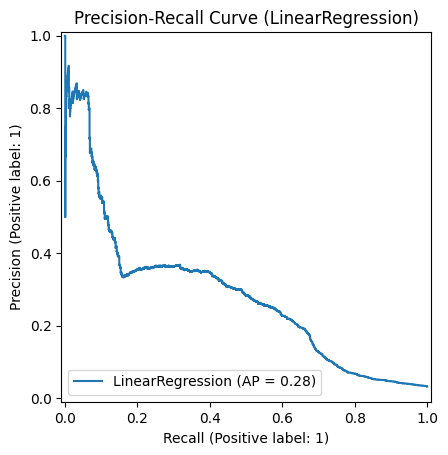

2025-06-14 19:18:15,484 - INFO - Verarbeite Modell: Ridge


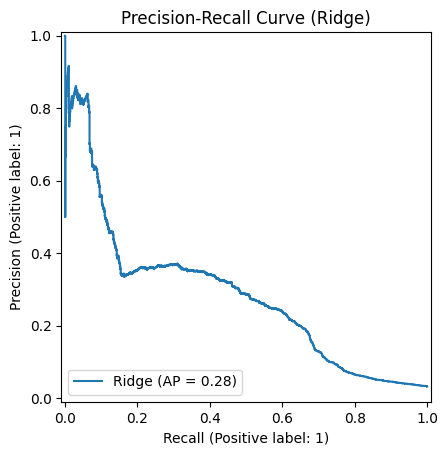

2025-06-14 19:29:40,062 - INFO - Verarbeite Modell: Lasso


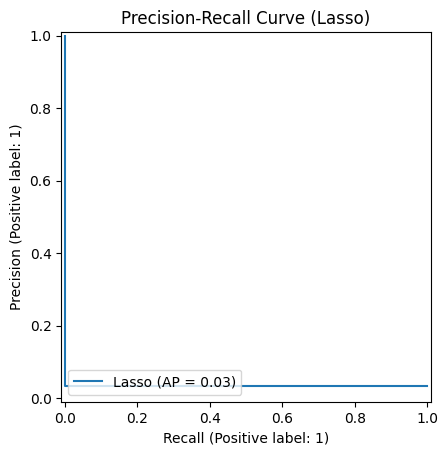

2025-06-14 19:43:08,003 - INFO - Verarbeite Modell: DecisionTree


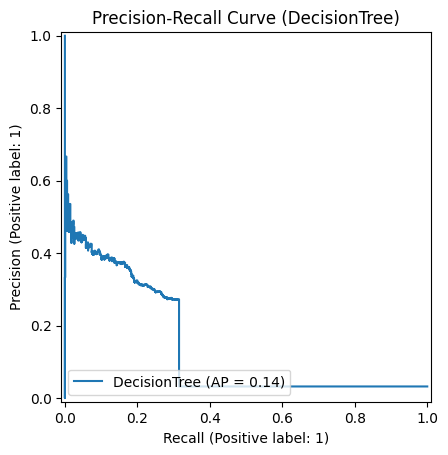

2025-06-14 19:53:10,321 - INFO - Verarbeite Modell: RandomForest


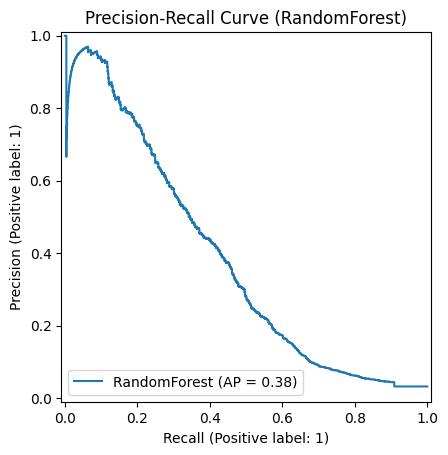

2025-06-14 20:04:56,177 - INFO - Verarbeite Modell: GradientBoosting


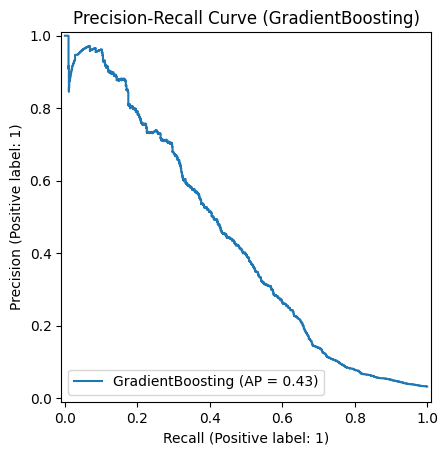

2025-06-14 20:16:06,942 - INFO - Verarbeite Modell: XGBoost


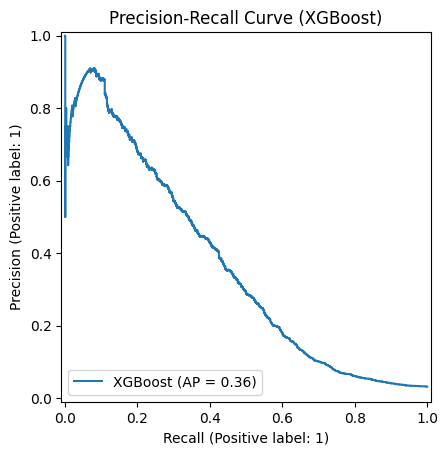

2025-06-14 20:26:18,353 - INFO - Verarbeite Modell: LightGBM


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3413
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 60
[LightGBM] [Info] Start training from score 0.252696


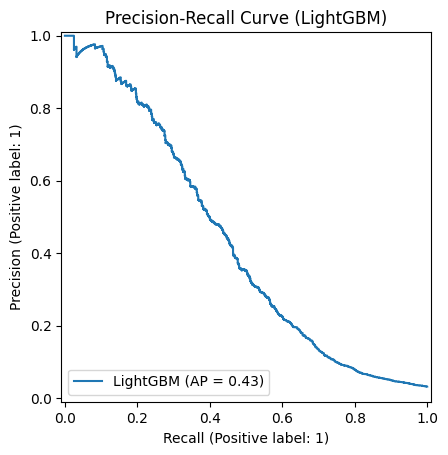

2025-06-14 20:41:37,070 - INFO - Verarbeite Modell: CatBoost


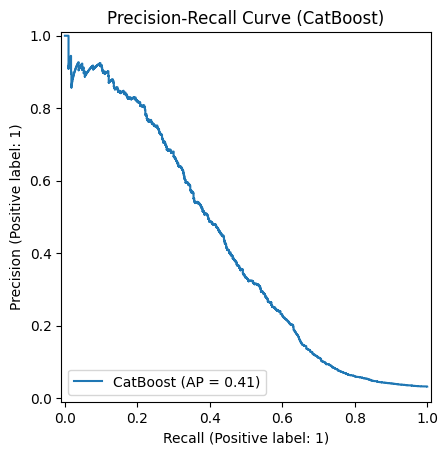

              Model  Best_Score  Threshold  accuracy  precision  recall  \
7          LightGBM    -4558.03   3.471041  0.973506   0.741047   0.269   
5  GradientBoosting    -4616.48   3.159145  0.973281   0.702899   0.291   
8          CatBoost    -4731.64   3.184135  0.972896   0.681395   0.293   
4      RandomForest    -5216.26   4.885178  0.972125   0.697605   0.233   
6           XGBoost    -5430.36   4.193647  0.971097   0.629534   0.243   
1             Ridge    -6841.07   3.254909  0.969524   0.807229   0.067   
0  LinearRegression    -6851.07   3.256859  0.969492   0.797619   0.067   
3      DecisionTree    -7654.27  15.644444  0.967436   0.444444   0.056   
2             Lasso  -296390.00   0.000000  0.032114   0.032114   1.000   

         f1   roc_auc  
7  0.394718  0.838399  
5  0.411598  0.839873  
8  0.409790  0.808502  
4  0.349325  0.808357  
6  0.350649  0.803746  
1  0.123730  0.822279  
0  0.123616  0.823406  
3  0.099467  0.644421  
2  0.062230  0.500000  


In [9]:
results = []
for name, pipeline in pipelines.items():
    logging.info(f"Verarbeite Modell: {name}")
    
    # 1. Einmaliges Training und Vorhersage
    pipeline.fit(X_train, damage_train)
    y_scores = pipeline.predict(X_test)
    
    # 2. Threshold-Optimierung und Metriken
    best_score, best_threshold, _ = evaluate_model(pipeline, X_test, damage_test, y_test)
    metrics = evaluate_classification_metrics(y_test, y_scores, best_threshold)
    
    # 3. Ergebnisse speichern
    results.append({
        'Model': name,
        'Best_Score': best_score,
        'Threshold': best_threshold,
        **metrics  # Alle Metriken entpacken
    })
    
    # 4. Plots (optional)
    PrecisionRecallDisplay.from_predictions(y_test, y_scores, name=name)
    plt.title(f'Precision-Recall Curve ({name})')
    plt.show()

# Ergebnisse anzeigen
results_df = pd.DataFrame(results).sort_values(by='Best_Score', ascending=False)
print(results_df[['Model', 'Best_Score', 'Threshold', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])

### Metriken für das beste Modell anzeigen

In [10]:
# Zeige alle gespeicherten Metriken für das beste Modell an
best_model_results = results_df.iloc[0]
print(f"\nBESTES MODELL: {best_model_results['Model']}")
print("Confusion Matrix:")
print(best_model_results['cm'])  # Funktioniert, wenn 'cm' im DataFrame ist
print(best_model_results['report'])


BESTES MODELL: LightGBM
Confusion Matrix:
[[30045    94]
 [  731   269]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30139
           1       0.74      0.27      0.39      1000

    accuracy                           0.97     31139
   macro avg       0.86      0.63      0.69     31139
weighted avg       0.97      0.97      0.97     31139



In [11]:
# 7. Metriken für alle Modelle anzeigen
for _, row in results_df.iterrows():
    print(f"\n\nMODELL: {row['Model']}")
    print("=" * 50)
    print(f"Custom Score: {row['Best_Score']:.2f}")
    print(f"Optimaler Threshold: {row['Threshold']:.4f}")
    print("\nConfusion Matrix:")
    print(row['cm'])
    print("\nKlassifikationsreport:")
    print(row['report'])
    print("\nWeitere Metriken:")
    print(f"Accuracy: {row['accuracy']:.4f}")
    print(f"Precision: {row['precision']:.4f}")
    print(f"Recall: {row['recall']:.4f}")
    print(f"F1-Score: {row['f1']:.4f}")
    print(f"ROC-AUC: {row['roc_auc']:.4f}")
    print("=" * 50)

# Zusätzlich das beste Modell hervorheben
best_model_results = results_df.iloc[0]
print(f"\n\nBESTES MODELL INSGESAMT: {best_model_results['Model']}")
print("=" * 50)
print(f"Custom Score: {best_model_results['Best_Score']:.2f}")
print("=" * 50)



MODELL: LightGBM
Custom Score: -4558.03
Optimaler Threshold: 3.4710

Confusion Matrix:
[[30045    94]
 [  731   269]]

Klassifikationsreport:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30139
           1       0.74      0.27      0.39      1000

    accuracy                           0.97     31139
   macro avg       0.86      0.63      0.69     31139
weighted avg       0.97      0.97      0.97     31139


Weitere Metriken:
Accuracy: 0.9735
Precision: 0.7410
Recall: 0.2690
F1-Score: 0.3947
ROC-AUC: 0.8384


MODELL: GradientBoosting
Custom Score: -4616.48
Optimaler Threshold: 3.1591

Confusion Matrix:
[[30016   123]
 [  709   291]]

Klassifikationsreport:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30139
           1       0.70      0.29      0.41      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.64      0.70     31139
wei

## Ergebnis:
Alle getesteten Regressionsmodelle wurden anhand der projektspezifischen Kostenfunktion sowie klassischer Klassifikationsmetriken bewertet. Insgesamt zeigt sich, dass insbesondere die Boosting-Modelle (GradientBoosting, LightGBM, CatBoost) die besten Ergebnisse erzielen und sowohl beim Custom Score als auch bei den Klassifikationsmetriken (Precision, Recall, F1-Score, ROC-AUC) überlegen sind. Die linearen Modelle (LinearRegression, Ridge, Lasso) sowie der DecisionTree liefern erwartungsgemäß schlechtere Resultate und zeigen insbesondere Schwächen beim Recall und der wirtschaftlichen Zielgröße. RandomForest und XGBoost bewegen sich leistungstechnisch zwischen den Boosting-Algorithmen und den klassischen Verfahren, erreichen aber nicht das Niveau der besten Modelle.

Die anschließende Hyperparameter-Optimierung wird daher auf die aussichtsreichsten Modelle GradientBoosting, LightGBM, CatBoost beschränkt.